# ERA V5 - Session 9: loss harness and output heads

Part 1: make next-token cross-entropy correct and observable.
Part 2: add a second head that predicts `t+2`.

Runtime > Run all. ~5 minutes on a free T4, longer on CPU.

In [1]:
!pip -q install tiktoken

## 0. Setup
One pip install (`tiktoken`), everything else is PyTorch. Runs on CPU or GPU.

In [2]:
import math, os, urllib.request
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.checkpoint import checkpoint
import tiktoken

torch.manual_seed(1337)
DEV = "cuda" if torch.cuda.is_available() else "cpu"

D_MODEL, N_HEAD, N_LAYER, BLOCK = 256, 4, 4, 128
BATCH, STEPS, LR = 16, 300, 3e-4
IGNORE = -100

enc = tiktoken.get_encoding("gpt2")
VOCAB = enc.n_vocab
print(f"device={DEV}  vocab={VOCAB}  d_model={D_MODEL}  layers={N_LAYER}  ctx={BLOCK}")

device=cuda  vocab=50257  d_model=256  layers=4  ctx=128


## 0.1 Data
Tiny Shakespeare over the wire, GPT-2 BPE, `V = 50,257`. A fallback string keeps the notebook runnable offline.

In [3]:
URL = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
try:
    text = urllib.request.urlopen(URL, timeout=20).read().decode()
except Exception as e:
    print("download failed, using fallback text:", e)
    text = ("To be, or not to be, that is the question: "
            "Whether 'tis nobler in the mind to suffer "
            "The slings and arrows of outrageous fortune. ") * 400

ids = torch.tensor(enc.encode(text), dtype=torch.long)
split = int(0.9 * len(ids))
train_ids, val_ids = ids[:split], ids[split:]
print(f"chars={len(text):,}  tokens={len(ids):,}  train={len(train_ids):,}  val={len(val_ids):,}")


def get_batch(source, batch=BATCH, block=BLOCK):
    i = torch.randint(len(source) - block - 2, (batch,))
    x = torch.stack([source[j:j + block + 2] for j in i])
    return x.to(DEV)

chars=1,115,394  tokens=338,025  train=304,222  val=33,803


## 0.2 Model
Small decoder in the shape of the session: pre-norm, RMSNorm, SwiGLU FFN, clean residual stream, untied output head.

In [4]:
class RMSNorm(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.g = nn.Parameter(torch.ones(d))

    def forward(self, x):
        return x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + 1e-6) * self.g


class Attention(nn.Module):
    def __init__(self):
        super().__init__()
        self.qkv = nn.Linear(D_MODEL, 3 * D_MODEL, bias=False)
        self.proj = nn.Linear(D_MODEL, D_MODEL, bias=False)

    def forward(self, x):
        B, T, D = x.shape
        q, k, v = self.qkv(x).split(D, dim=2)
        q, k, v = [t.view(B, T, N_HEAD, D // N_HEAD).transpose(1, 2) for t in (q, k, v)]
        o = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        return self.proj(o.transpose(1, 2).reshape(B, T, D))


class SwiGLU(nn.Module):
    def __init__(self):
        super().__init__()
        hidden = int(8 / 3 * D_MODEL / 64) * 64          # ~2.7x, rounded for hardware
        self.gate = nn.Linear(D_MODEL, hidden, bias=False)
        self.up = nn.Linear(D_MODEL, hidden, bias=False)
        self.down = nn.Linear(hidden, D_MODEL, bias=False)

    def forward(self, x):
        return self.down(F.silu(self.gate(x)) * self.up(x))


class Block(nn.Module):
    def __init__(self):
        super().__init__()
        self.n1, self.attn = RMSNorm(D_MODEL), Attention()
        self.n2, self.ffn = RMSNorm(D_MODEL), SwiGLU()

    def forward(self, x):                                # pre-norm: residual stream stays clean
        x = x + self.attn(self.n1(x))
        return x + self.ffn(self.n2(x))


class Model(nn.Module):
    """Trunk + head1 (t+1). head2 (t+2) is added in Part 2."""

    def __init__(self, extra_head=False):
        super().__init__()
        self.tok = nn.Embedding(VOCAB, D_MODEL)
        self.pos = nn.Embedding(BLOCK + 2, D_MODEL)
        self.blocks = nn.ModuleList(Block() for _ in range(N_LAYER))
        self.norm = RMSNorm(D_MODEL)
        self.head1 = nn.Linear(D_MODEL, VOCAB, bias=False)
        self.head2 = nn.Linear(D_MODEL, VOCAB, bias=False) if extra_head else None

    def hidden(self, idx):
        T = idx.size(1)
        x = self.tok(idx) + self.pos(torch.arange(T, device=idx.device))
        for b in self.blocks:
            x = b(x)
        return self.norm(x)

    def forward(self, idx):
        return self.head1(self.hidden(idx))


model = Model().to(DEV)
print(f"trunk+head params: {sum(p.numel() for p in model.parameters()):,}")

trunk+head params: 28,781,824


## 1. Every tensor shape, and what each dimension is

In [5]:
xb = get_batch(train_ids)[:, :BLOCK]
h = model.hidden(xb)
logits = model.head1(h)

print(f"tokens  {tuple(xb.shape)}      B=batch, T=context position")
print(f"hidden  {tuple(h.shape)} B=batch, T=position, D=d_model (meaning of the token in context)")
print(f"logits  {tuple(logits.shape)} B=batch, T=position, V=vocab (one raw score per token)")
print(f"flat    {tuple(logits[:, :-1].reshape(-1, VOCAB).shape)}   (B*(T-1))=scored positions, V=vocab")
print(f"targets {tuple(xb[:, 1:].reshape(-1).shape)}          one gold token id per scored position")
print(f"logits tensor is {VOCAB / D_MODEL:.0f}x larger than the hidden state that produced it")

tokens  (16, 128)      B=batch, T=context position
hidden  (16, 128, 256) B=batch, T=position, D=d_model (meaning of the token in context)
logits  (16, 128, 50257) B=batch, T=position, V=vocab (one raw score per token)
flat    (2032, 50257)   (B*(T-1))=scored positions, V=vocab
targets (2032,)          one gold token id per scored position
logits tensor is 196x larger than the hidden state that produced it


## 2. Verify the shift by reading strings, not ids
An off-by-one is invisible in a wall of integers.

In [6]:
row = xb[0, :12].tolist()
inp, tgt = row[:-1], row[1:]
print(f"{'position':<9}{'input':<18}{'target':<18}")
for p, (a, b) in enumerate(zip(inp, tgt)):
    print(f"{p:<9}{repr(enc.decode([a])):<18}{repr(enc.decode([b])):<18}")
print("\ninput  text:", repr(enc.decode(inp)))
print("target text:", repr(enc.decode(tgt)))
print("target is the input shifted left by one -> shift is correct")

position input             target            
0        ' whence'         " '"              
1        " '"              'tis'             
2        'tis'             ' derived'        
3        ' derived'        '.'               
4        '.'               '\n'              
5        '\n'              'There'           
6        'There'           ' is'             
7        ' is'             ' another'        
8        ' another'        ' fri'            
9        ' fri'            'ar'              
10       'ar'              ' that'           

input  text: " whence 'tis derived.\nThere is another friar"
target text: " 'tis derived.\nThere is another friar that"
target is the input shifted left by one -> shift is correct


## 3. Mask padding
PAD is not a prediction. Watch the contributing-token count fall.

In [7]:
pad_batch = xb[:4, :16].clone()
pad_batch[1, 10:] = pad_batch[2, 12:] = pad_batch[3, 8:] = 0     # 0 = PAD
pad_keep = torch.ones_like(pad_batch, dtype=torch.bool)
pad_keep[1, 10:] = pad_keep[2, 12:] = pad_keep[3, 8:] = False


def pad_check(m, tag):
    with torch.no_grad():
        lg = m(pad_batch)[:, :-1].reshape(-1, VOCAB)
    tg = pad_batch[:, 1:].reshape(-1)
    tg_m = tg.masked_fill(~pad_keep[:, 1:].reshape(-1), IGNORE)
    a = F.cross_entropy(lg, tg).item()
    b = F.cross_entropy(lg, tg_m, ignore_index=IGNORE).item()
    print(f"[{tag}] pad counted: loss {a:.4f} over {tg.numel()} tokens | "
          f"pad masked: loss {b:.4f} over {(tg_m != IGNORE).sum().item()} tokens")
    return a, b, tg.numel(), (tg_m != IGNORE).sum().item()


pad_in, pad_out, n_pad_all, n_pad_kept = pad_check(model, "untrained")
print("the mean must divide by contributing tokens, not B*T (re-checked after training in Part 2)")

[untrained] pad counted: loss 10.9079 over 60 tokens | pad masked: loss 10.9335 over 42 tokens
the mean must divide by contributing tokens, not B*T (re-checked after training in Part 2)


## 4. Mask the document boundary
Two packed documents. The last token of A must not predict the first token of B.

In [8]:
doc_a = enc.encode("The capital of India is New Delhi and the weather there is cold in winter.")[:BLOCK // 2]
doc_b = enc.encode("Cryptography relies on hard problems such as factoring large integers.")[:BLOCK // 2]
packed = torch.tensor([doc_a + doc_b], device=DEV)
boundary = len(doc_a) - 1                      # last token of doc A would predict first of doc B


def boundary_check(m, tag):
    with torch.no_grad():
        lg = m(packed)[:, :-1].reshape(-1, VOCAB)
    tg = packed[:, 1:].reshape(-1)
    tg_m = tg.clone()
    tg_m[boundary] = IGNORE
    a = F.cross_entropy(lg, tg).item()
    b = F.cross_entropy(lg, tg_m, ignore_index=IGNORE).item()
    print(f"[{tag}] boundary trained: loss {a:.4f} over {tg.numel()} tokens | "
          f"boundary masked: loss {b:.4f} over {(tg_m != IGNORE).sum().item()} tokens")
    return a, b, tg.numel(), (tg_m != IGNORE).sum().item()


bnd_in, bnd_out, n_bnd_all, n_bnd_kept = boundary_check(model, "untrained")
print(f"crossing pair: {enc.decode([packed[0, boundary].item()])!r} -> "
      f"{enc.decode([packed[0, boundary + 1].item()])!r}  -- unrelated documents, must not be trained")

[untrained] boundary trained: loss 10.9097 over 28 tokens | boundary masked: loss 10.8854 over 27 tokens
crossing pair: '.' -> 'Crypt'  -- unrelated documents, must not be trained


## 5. Perplexity sanity check
An untrained model must start near `ln(V)`. If it doesn't, the targets are wrong.

In [9]:
fresh = Model().to(DEV)
with torch.no_grad():
    lg = fresh(xb)[:, :-1].reshape(-1, VOCAB)
loss0 = F.cross_entropy(lg, xb[:, 1:].reshape(-1))
print(f"untrained loss       {loss0:.4f}   expected ln(V) = {math.log(VOCAB):.4f}")
print(f"untrained perplexity {math.exp(loss0):,.0f}   expected V = {VOCAB:,}")
print("start far from this and the target alignment is wrong -- stop and debug")

untrained loss       10.9808   expected ln(V) = 10.8249
untrained perplexity 58,736   expected V = 50,257
start far from this and the target alignment is wrong -- stop and debug


## 6. Tied vs untied head parameters

In [10]:
trunk = sum(p.numel() for n, p in model.named_parameters() if not n.startswith("head"))
head = VOCAB * D_MODEL
print(f"trunk                {trunk:,}")
print(f"untied  (emb + head) {2 * head:,}  total {trunk + head:,}")
print(f"tied    (emb = head) {head:,}  total {trunk:,}")
print(f"tying saves {head:,} params ({head / (trunk + head):.1%} of the untied model)")

trunk                15,916,032
untied  (emb + head) 25,731,584  total 28,781,824
tied    (emb = head) 12,865,792  total 15,916,032
tying saves 12,865,792 params (44.7% of the untied model)


## 7. Naive vs chunked cross-entropy
Same loss, same gradient, a fraction of the peak logits memory. Backward recomputes each chunk.

In [11]:
def naive_ce(h, W, targets):
    return F.cross_entropy(h @ W.t(), targets, ignore_index=IGNORE)


CHUNK = 256


def chunked_ce(h, W, targets, chunk=CHUNK):
    total, n = 0.0, 0
    for i in range(0, h.size(0), chunk):
        hb, tb = h[i:i + chunk], targets[i:i + chunk]
        step = lambda a, b: F.cross_entropy(a @ W.t(), b, ignore_index=IGNORE, reduction="sum")
        total = total + (checkpoint(step, hb, tb, use_reentrant=False) if hb.requires_grad else step(hb, tb))
        n += (tb != IGNORE).sum()
    return total / n


def peak_memory(fn):
    if DEV == "cuda":
        torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()
        loss = fn(); loss.backward()
        return loss.item(), torch.cuda.max_memory_allocated()
    loss = fn(); loss.backward()
    return loss.item(), None


hh = model.hidden(xb).detach()[:, :-1].reshape(-1, D_MODEL).requires_grad_(True)
tt = xb[:, 1:].reshape(-1)
W = model.head1.weight

l_naive, m_naive = peak_memory(lambda: naive_ce(hh, W, tt))
g_naive = hh.grad.clone(); hh.grad = None
l_chunk, m_chunk = peak_memory(lambda: chunked_ce(hh, W, tt))
g_diff = (g_naive - hh.grad).abs().max().item()

N = hh.size(0)
an_naive = N * VOCAB * 4
an_chunk = min(CHUNK, N) * VOCAB * 4
print(f"loss naive   {l_naive:.6f}")
print(f"loss chunked {l_chunk:.6f}   identical: {abs(l_naive - l_chunk) < 1e-5}   max grad diff {g_diff:.2e}")
if m_naive:
    print(f"peak measured  naive {m_naive/2**20:8.1f} MiB   chunked {m_chunk/2**20:8.1f} MiB   "
          f"ratio {m_naive/m_chunk:.1f}x")
else:
    print("peak measured: GPU only (running on CPU)")
print(f"peak logits    naive {an_naive/2**20:8.1f} MiB   chunked {an_chunk/2**20:8.1f} MiB   "
      f"ratio {an_naive/an_chunk:.1f}x   [analytic, N x V x 4B]")

loss naive   10.991126
loss chunked 10.991125   identical: True   max grad diff 0.00e+00
peak measured  naive   2350.4 MiB   chunked   1437.9 MiB   ratio 1.6x
peak logits    naive    389.6 MiB   chunked     49.1 MiB   ratio 7.9x   [analytic, N x V x 4B]


## Part 2. A second head predicting t+2
One trunk, two heads, the two losses add.

In [12]:
mtp = Model(extra_head=True).to(DEV)
opt = torch.optim.AdamW(mtp.parameters(), lr=LR)
log = []

for step in range(1, STEPS + 1):
    b = get_batch(train_ids)
    h = mtp.hidden(b[:, :BLOCK])
    l1 = F.cross_entropy(mtp.head1(h).reshape(-1, VOCAB), b[:, 1:BLOCK + 1].reshape(-1))
    l2 = F.cross_entropy(mtp.head2(h).reshape(-1, VOCAB), b[:, 2:BLOCK + 2].reshape(-1))
    loss = l1 + l2
    opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
    if step % 25 == 0 or step == 1:
        log.append((step, l1.item(), l2.item(), loss.item()))
        print(f"step {step:4d}   head1 {l1:.4f}   head2 {l2:.4f}   sum {loss:.4f}")

step    1   head1 10.9812   head2 11.0004   sum 21.9816
step   25   head1 8.1889   head2 8.4590   sum 16.6479
step   50   head1 6.5976   head2 6.7347   sum 13.3322
step   75   head1 6.3984   head2 6.5021   sum 12.9004
step  100   head1 6.1382   head2 6.2878   sum 12.4260
step  125   head1 6.0336   head2 6.2356   sum 12.2692
step  150   head1 5.9832   head2 6.2052   sum 12.1884
step  175   head1 5.9008   head2 6.1978   sum 12.0986
step  200   head1 5.5704   head2 5.8785   sum 11.4488
step  225   head1 5.5148   head2 5.8553   sum 11.3701
step  250   head1 5.4929   head2 5.9315   sum 11.4244
step  275   head1 5.4055   head2 5.8623   sum 11.2678
step  300   head1 5.4826   head2 5.9489   sum 11.4316


## Part 2b. Re-run the mask checks on the trained model
Now counting PAD visibly flatters the loss.

In [13]:
pad_in_t, pad_out_t, _, _ = pad_check(mtp, "trained  ")
bnd_in_t, bnd_out_t, _, _ = boundary_check(mtp, "trained  ")
print("counting PAD now flatters the loss -- PAD is trivially predictable once trained")

[trained  ] pad counted: loss 5.7769 over 60 tokens | pad masked: loss 5.4542 over 42 tokens
[trained  ] boundary trained: loss 9.3517 over 28 tokens | boundary masked: loss 9.1732 over 27 tokens
counting PAD now flatters the loss -- PAD is trivially predictable once trained


## Part 2c. Both head losses

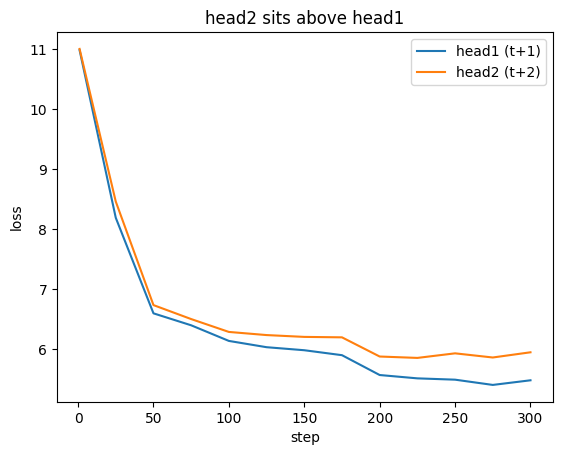

In [14]:
import matplotlib.pyplot as plt
s, a, b_, c = zip(*log)
plt.plot(s, a, label="head1 (t+1)")
plt.plot(s, b_, label="head2 (t+2)")
plt.xlabel("step"); plt.ylabel("loss"); plt.legend(); plt.title("head2 sits above head1")
plt.show()

In [15]:
print("== numbers for the write-up ==")
print(f"1 logits shape           {tuple(logits.shape)}  ({VOCAB/D_MODEL:.0f}x the hidden state)")
print(f"2 shift check            passed (strings printed above)")
print(f"3 padding  (trained)     {pad_in_t:.4f} -> {pad_out_t:.4f}   tokens {n_pad_all} -> {n_pad_kept}")
print(f"4 boundary (trained)     {bnd_in_t:.4f} -> {bnd_out_t:.4f}   tokens {n_bnd_all} -> {n_bnd_kept}")
print(f"5 untrained loss/ppl     {loss0:.4f} / {math.exp(loss0):,.0f}   (ln V = {math.log(VOCAB):.4f})")
print(f"6 tied vs untied         {trunk + head:,} -> {trunk:,}  (saves {head:,})")
print(f"7 CE peak logits         {an_naive/2**20:.1f} MiB -> {an_chunk/2**20:.1f} MiB "
      f"({an_naive/an_chunk:.0f}x), loss identical")
print(f"8 head1 / head2 / sum    {log[-1][1]:.4f} / {log[-1][2]:.4f} / {log[-1][3]:.4f}")

== numbers for the write-up ==
1 logits shape           (16, 128, 50257)  (196x the hidden state)
2 shift check            passed (strings printed above)
3 padding  (trained)     5.7769 -> 5.4542   tokens 60 -> 42
4 boundary (trained)     9.3517 -> 9.1732   tokens 28 -> 27
5 untrained loss/ppl     10.9808 / 58,736   (ln V = 10.8249)
6 tied vs untied         28,781,824 -> 15,916,032  (saves 12,865,792)
7 CE peak logits         389.6 MiB -> 49.1 MiB (8x), loss identical
8 head1 / head2 / sum    5.4826 / 5.9489 / 11.4316
